# 04. Recomendador con embeddings (Modelo 2) vs TF-IDF (Modelo 1)

Este notebook construye el **segundo modelo de recomendación** del proyecto y lo compara, con datos, contra el primero.

| | Modelo 1 (baseline) | Modelo 2 (este notebook) |
|---|---|---|
| Representación | **TF-IDF** (vector disperso por palabras / bigramas) | **Embedding** (vector denso por significado) |
| Similitud | coseno | coseno |
| Notebook | `03_recomendador_content_based.ipynb` | `04_recomendador_embeddings.ipynb` |
| Artefactos | `models/tfidf_vectorizer.joblib`, `models/recipe_tfidf_matrix.joblib` | `models/recipe_embeddings.npy`, `models/embedding_metadata.json`, `models/embedding_model/` |

```text
recipe_text ──► TF-IDF ───────► vector disperso ─┐
                                                  ├─► coseno ─► ranking ─► Top-N ─► métricas
recipe_text ──► modelo de embeddings ► vector denso ┘
```

**Qué se mantiene idéntico** (para aislar la única variable experimental, *la representación*): el mismo CSV, el mismo `recipe_text`, el mismo conjunto de consultas, la misma definición de relevancia, los mismos K y las mismas métricas.

**Qué NO hace este notebook:** no modifica el Modelo 1 (sus archivos en `models/` solo se *leen*), no toca backend ni frontend, no implementa el chatbot ni añade base de datos.

> ## Aviso importante sobre la evaluación
> El notebook 03 termina diciendo que *"la siguiente etapa será crear casos de prueba y métricas de ranking"*: **en el proyecto no existía ningún conjunto de evaluación ni métricas calculadas del Modelo 1** (se revisaron los notebooks 01–03, `src/`, `models/`, `tests/` y el historial). Por eso, aquí se define **una sola vez** un conjunto de evaluación congelado (`data/evaluation/eval_set_v1.json`) y se aplica **exactamente igual a los dos modelos**, incluido el Modelo 1. La sección 9 explica cómo se define la relevancia y sus límites. Si más adelante aparece un conjunto de evaluación previo, basta con sustituir ese archivo: el resto del código no cambia.

## 1. Conceptos: de TF-IDF a embeddings, aplicados a recetas

### 1.1 ¿Qué es un embedding?
Un **embedding** es un vector de números (aquí, 384) que un modelo de lenguaje entrenado con muchísimo texto asigna a un fragmento de texto. El entrenamiento hace que **textos con significado parecido queden cerca** en ese espacio, aunque no compartan las mismas palabras.

### 1.2 ¿En qué se diferencia de TF-IDF?
| | TF-IDF | Embeddings |
|---|---|---|
| Qué mide | **qué palabras aparecen** y cuán raras son | **de qué trata** el texto (significado aprendido) |
| Dimensión | ~63 mil (un eje por palabra/bigrama del vocabulario) | 384 (ejes sin significado individual) |
| Forma | dispersa: casi todo ceros | densa: todos los valores son distintos de cero |
| Sinónimos | `jitomate` y `tomate` son ejes distintos → similitud 0 | pueden quedar cerca |
| Palabras fuera del vocabulario | se ignoran | se descomponen en sub-palabras |
| Qué necesita | solo los datos del proyecto (se "entrena" en segundos) | un modelo preentrenado externo (cientos de MB) |
| Interpretabilidad | alta: se ve qué palabras pesan | baja: no se puede "leer" un vector |

### 1.3 ¿Qué representa el embedding de una receta?
El modelo lee el `recipe_text` (nombre + ingredientes + etiquetas + país + dificultad) y lo resume en **un vector**. Es una "huella de significado" de la receta: dos recetas cuya huella apunta en direcciones parecidas deberían ser platos parecidos.

### 1.4 ¿Qué es la similitud coseno?
Mide el **ángulo** entre dos vectores (no su longitud):

$$\cos(a, b) = \frac{a \cdot b}{\lVert a\rVert\,\lVert b\rVert}$$

Cerca de 1 → misma dirección (muy parecidas); cerca de 0 → sin relación (en TF-IDF); en embeddings los valores suelen estar comprimidos en un rango alto, por lo que **solo importa el orden, no el valor absoluto**. Si los vectores se normalizan a norma 1 (como hace el proyecto en ambos modelos), el coseno es simplemente el producto punto, y por eso **nunca se necesita una matriz receta × receta**: una consulta calcula N similitudes.

### 1.5 ¿Por qué comparar embeddings contra TF-IDF?
Porque el TF-IDF es el baseline del proyecto y la pregunta de negocio es concreta: **¿vale la pena el costo extra (modelo externo, torch, más memoria) de los embeddings, o TF-IDF ya recomienda igual de bien?** Los embeddings tienen fama de ser mejores, pero eso hay que **medirlo**, no asumirlo.

### 1.6 Limitaciones de cada enfoque
| TF-IDF | Embeddings |
|---|---|
| No entiende sinónimos ni regionalismos (`jitomate`/`tomate`, `frijoles`/`alubias`/`judías`) | Dependen de un modelo externo que no se entrenó con recetas |
| Un bigrama coincidente pesa mucho aunque el contexto sea distinto | Pueden confundir "parecido temático" con "mismo tipo de plato" (p. ej. juntar todo lo "mexicano") |
| Sensible a ruido léxico del texto (etiquetas repetidas, marcas) | Contexto máximo del modelo: textos más largos se truncan |
| — | Menos interpretables y más costosos de calcular, almacenar y servir |

**Ninguno modela gustos de usuarios**: ambos miden similitud de *contenido*.

## 2. Dependencias y reproducibilidad

```bash
# desde la raíz del proyecto
source .venv/bin/activate
pip install -r requirements.txt     # incluye sentence-transformers (instala torch y transformers)
jupyter lab                         # o abrir este notebook en Cursor/VS Code con el kernel del .venv
```

* **Librería de embeddings:** [`sentence-transformers`](https://www.sbert.net/) (envuelve `transformers` + `torch`). Es la opción estándar para embeddings de oraciones/documentos: da el modelo, el *pooling* y la normalización ya resueltos, y `encode()` procesa por batches.
* **Primera ejecución:** descarga el modelo desde Hugging Face (~470 MB, requiere internet) y lo guarda en `models/embedding_model/`; las siguientes ejecuciones lo cargan **sin red**.
* **Embeddings:** se calculan **una sola vez** y se guardan en `models/recipe_embeddings.npy`; si ya existen y corresponden al CSV y al modelo configurado, se cargan en vez de recalcularse.
* **Cambiar de modelo:** una sola constante, `EMBEDDING_MODEL_NAME` en `src/embeddings.py` (o la variable de entorno `CHEFWISE_EMBEDDING_MODEL`). Nada más del código usa el nombre.
* **Sin tocar el Modelo 1:** los archivos `tfidf_vectorizer.joblib` y `recipe_tfidf_matrix.joblib` solo se leen.

In [1]:
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Funciona con Jupyter ejecutándose en la raíz del proyecto o en notebooks/
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from src import embeddings as emb
from src import evaluation as ev
from src.exceptions import ArtifactMismatchError, ArtifactNotFoundError
from src.models import load_artifacts, validate_alignment

DATA_PATH = PROJECT_DIR / "data" / "processed" / "recetas_unificadas_limpias.csv"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "notebooks" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Único punto donde se decide el modelo de embeddings (definido en src/embeddings.py)
EMBEDDING_MODEL_NAME = emb.EMBEDDING_MODEL_NAME
QUERY_PREFIX, PASSAGE_PREFIX = emb.default_prefixes(EMBEDDING_MODEL_NAME)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

print("Proyecto:", PROJECT_DIR)
print("CSV:", DATA_PATH)
print("Modelo de embeddings configurado:", EMBEDDING_MODEL_NAME)
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)
print("Librerías de embeddings:", emb.library_versions())

Proyecto: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise
CSV: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/processed/recetas_unificadas_limpias.csv
Modelo de embeddings configurado: intfloat/multilingual-e5-small
Python 3.13.0 | numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1


Librerías de embeddings: {'sentence_transformers': '6.1.0', 'torch': '2.14.1', 'transformers': '5.18.0', 'numpy': '2.5.3'}


## 3. Dataset: el mismo CSV y el mismo `recipe_text` del Modelo 1

El notebook 03 usa `data/processed/recetas_unificadas_limpias.csv` y alimenta TF-IDF con la columna `recipe_text`, construida en el notebook 01 así:

```text
recipe_text = nombre | ingredientes | category_tags | diet_tags | meal_type | app_category | country | difficulty
```

(los pasos de preparación **no** entran a propósito). Aquí se usa **la misma columna sin ninguna modificación**: así el único cambio entre modelos es cómo se convierte ese texto en un vector.

In [2]:
df = pd.read_csv(DATA_PATH)

assert df["recipe_id"].is_unique, "recipe_id debe ser único"
assert df["recipe_text"].notna().all() and (df["recipe_text"].str.strip() != "").all()

texts = df["recipe_text"].astype(str).tolist()          # exactamente lo que recibió TF-IDF en el notebook 03
recipe_ids = df["recipe_id"].to_numpy()
id_to_pos = {int(r): i for i, r in enumerate(recipe_ids)}

print("Recetas:", len(df), "| columnas:", df.shape[1])
print("\nEjemplo de recipe_text (receta", int(recipe_ids[5]), "):\n", texts[5][:600])

Recetas: 28853 | columnas: 29

Ejemplo de recipe_text (receta 6 ):
 Tacos de Cerdo con Salsa Roja | 20 unidades de Tortillas de maíz amarillo | 100 gramos de Lechuga picada | 200 gramos de Frijoles refritos | 700 gramos de Pierna de cerdo | 4 unidades de Tomate rojo | 2 unidades de Cebolla morada pequeña | 30 gramos de Cilantro | 1 unidad de Chile chipotle ahumado | 1 unidad de Limón | 50 mililitros de Aceite neutro | 3 dientes de Ajo | 5 gramos de Tallos de cilantro | 35 mililitros de Salsa inglesa | 2 gramos de Comino en polvo | 3 unidades de Tomates rojos firmes | 1 unidad de Cebolla roja | 20 gramos de Cilantro | 1 unidad de Limón | 30 mililitros de Aceite


## 4. Elección del modelo de embeddings (decisión documentada)

**Requisitos derivados del proyecto:**

1. El texto está en **español** (con regionalismos de México, España y Sudamérica) → modelo **multilingüe** con español en su preentrenamiento.
2. Es **recuperación de documentos cortos** (≈ 125 tokens de media) → un modelo de *embeddings de recuperación/similitud* (no un LLM generativo).
3. El `recipe_text` **termina con las etiquetas** (categoría, país, dificultad) → un contexto máximo corto **truncaría justo esa parte**.
4. El proyecto no exige GPU y debe poder ejecutarse en un portátil → tamaño moderado.
5. Debe ser abierto, descargable sin cuenta y compatible con `sentence-transformers`.

**Candidatos considerados** (cifras tomadas de las fichas públicas de cada modelo en Hugging Face; en este notebook solo se verifican las del modelo elegido, en la celda siguiente):

| Modelo | Dim. | Contexto máx. | Parámetros aprox. | Comentario |
|---|---|---|---|---|
| `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` | 384 | 128 tokens | 118 M | Rápido, pero 128 tokens es poco (ver análisis abajo) |
| `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` | 768 | 128 tokens | 278 M | Mismo límite de contexto, el doble de dimensión |
| **`intfloat/multilingual-e5-small`** | **384** | **512 tokens** | **118 M** | Multilingüe, entrenado para recuperación, contexto suficiente, ligero |
| `intfloat/multilingual-e5-base` | 768 | 512 tokens | 278 M | Más capacidad; más lento y 2× memoria |
| `BAAI/bge-m3` | 1024 | 8192 tokens | 568 M | Muy potente, pero pesado para un baseline en CPU/portátil |

**Decisión: `intfloat/multilingual-e5-small`.** Cumple los cinco requisitos con el menor costo; es el candidato multilingüe más pequeño con contexto de 512 tokens. Se eligió **antes de ver ninguna métrica** y **no se probaron otros modelos contra el conjunto de evaluación** (hacerlo y quedarse con el mejor sería *seleccionar sobre el conjunto de prueba*). Si el resultado sugiere que vale la pena, `multilingual-e5-base` / `bge-m3` quedan como el siguiente experimento: basta con cambiar `EMBEDDING_MODEL_NAME`.

**Detalle de uso de E5:** esta familia se entrenó con prefijos. Las recetas se codifican con `"passage: "` y las consultas de texto libre con `"query: "`. Se centraliza en `emb.default_prefixes()`.

In [3]:
LOCAL_MODEL_DIR = MODELS_DIR / emb.EMBEDDING_MODEL_DIRNAME

if LOCAL_MODEL_DIR.is_dir():
    print("Cargando el modelo desde la copia local:", LOCAL_MODEL_DIR)
    model = emb.load_embedding_model(LOCAL_MODEL_DIR)
else:
    print("Descargando el modelo desde Hugging Face:", EMBEDDING_MODEL_NAME)
    model = emb.load_embedding_model(EMBEDDING_MODEL_NAME)

print("\nModelo:", EMBEDDING_MODEL_NAME)
print("Dimensión del embedding:", emb.embedding_dimension(model))
print("Contexto máximo (tokens):", model.max_seq_length)
print("Dispositivo:", model.device)
print("Prefijos -> consulta:", repr(QUERY_PREFIX), "| documento:", repr(PASSAGE_PREFIX))

Cargando el modelo desde la copia local: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/models/embedding_model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Modelo: intfloat/multilingual-e5-small
Dimensión del embedding: 384
Contexto máximo (tokens): 512
Dispositivo: mps:0
Prefijos -> consulta: 'query: ' | documento: 'passage: '


### 4.1 Comprobación con datos: ¿cuántas recetas truncaría cada límite de contexto?
Se tokeniza **todo** el `recipe_text` con el tokenizador real del modelo elegido y se mira cuántas recetas superarían 128 y 512 tokens (el texto sobrante se descartaría).

In [4]:
token_counts = np.array([len(ids) for ids in model.tokenizer(texts, add_special_tokens=True)["input_ids"]])

summary = pd.Series({
    "media": token_counts.mean(), "mediana": np.median(token_counts),
    "p90": np.percentile(token_counts, 90), "p99": np.percentile(token_counts, 99), "máximo": token_counts.max(),
}).round(1)
print(summary.to_string(), "\n")
for limit in (128, 256, 512):
    share = (token_counts > limit).mean()
    print(f"Recetas con más de {limit:>3} tokens: {int((token_counts > limit).sum()):>6} ({share:6.2%})")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (862 > 512). Running this sequence through the model will result in indexing errors


media      122.8
mediana    113.0
p90        187.0
p99        313.0
máximo     894.0 

Recetas con más de 128 tokens:  10755 (37.28%)
Recetas con más de 256 tokens:    732 ( 2.54%)
Recetas con más de 512 tokens:     18 ( 0.06%)


## 5. Generar la matriz de embeddings (una sola vez)

```text
recipe_text ─► [passage: ...] ─► modelo ─► vector (384) ─► normalizado L2 ─► fila de la matriz (N × 384)
```

* Se procesa **por batches** (`EMBEDDING_BATCH_SIZE`), así la memoria no crece con N.
* Los vectores se normalizan a norma 1 → el coseno es un producto punto.
* Si `models/recipe_embeddings.npy` ya existe **y** su huella coincide con el `recipe_text` actual y con el modelo configurado, **se carga** (no se recalcula). Si no, se genera y se guarda junto con sus metadatos (modelo, dimensión, versiones, tiempo).
* El orden de filas es el del CSV, igual que en la matriz TF-IDF.

In [5]:
try:
    emb_art = emb.load_embedding_artifacts(
        MODELS_DIR, texts=texts, expected_model_name=EMBEDDING_MODEL_NAME, load_model=False
    )
    emb_art.model = model
    print("Embeddings CARGADOS desde models/ (no se recalcularon).")
    freshly_built = False
except (ArtifactNotFoundError, ArtifactMismatchError) as exc:
    print("No hay embeddings válidos en models/ -> se generan ahora.\nMotivo:", exc, "\n")
    emb_art = emb.build_embeddings(texts, model_name=EMBEDDING_MODEL_NAME, model=model, show_progress_bar=True)
    saved = emb.save_embedding_artifacts(emb_art, MODELS_DIR)
    print("\nGuardado:", {k: str(v.relative_to(PROJECT_DIR)) for k, v in saved.items()})
    freshly_built = True

meta = emb_art.metadata
E = emb_art.matrix
print("\n--- Resumen de la representación ---")
print("Número de recetas      :", E.shape[0])
print("Dimensión del embedding:", E.shape[1])
print("Forma de la matriz     :", E.shape, "| dtype:", E.dtype)
print(f"Tamaño en memoria      : {E.nbytes / 1e6:.1f} MB")
print(f"Tiempo de generación   : {meta['build_seconds']} s en dispositivo '{meta['device']}' (batch={meta['batch_size']})")
print("Normas L2 (min, max)   :", float(np.linalg.norm(E, axis=1).min()), float(np.linalg.norm(E, axis=1).max()))
print("Modelo / librerías     :", meta["model_name"], meta["libraries"])

Embeddings CARGADOS desde models/ (no se recalcularon).

--- Resumen de la representación ---
Número de recetas      : 28853
Dimensión del embedding: 384
Forma de la matriz     : (28853, 384) | dtype: float32
Tamaño en memoria      : 44.3 MB
Tiempo de generación   : 81.8 s en dispositivo 'mps:0' (batch=64)
Normas L2 (min, max)   : 0.9999998807907104 1.0000001192092896
Modelo / librerías     : intfloat/multilingual-e5-small {'sentence_transformers': '6.1.0', 'torch': '2.14.1', 'transformers': '5.18.0', 'numpy': '2.5.3'}


## 6. Modelo 1 (TF-IDF): se carga tal cual, sin modificarlo

Se usan los artefactos guardados en `models/` mediante la utilidad que ya usa el backend (`src.models.load_artifacts`) y se valida que correspondan al CSV (`validate_alignment`). **No se reescribe ningún archivo del Modelo 1.**

Para poder medir el *tiempo de construcción* del TF-IDF, se vuelve a ajustar un vectorizador **en memoria** con los mismos hiperparámetros del notebook 03 y se comprueba que reproduce exactamente la matriz guardada. Ese vectorizador de prueba no se guarda.

In [6]:
m1 = load_artifacts(MODELS_DIR)
validate_alignment(m1, texts)
tfidf, tfidf_matrix = m1.vectorizer, m1.matrix
print("TF-IDF cargado:", tfidf_matrix.shape, type(tfidf_matrix).__name__, "| hiperparámetros:",
      {k: tfidf.get_params()[k] for k in ("lowercase", "strip_accents", "ngram_range", "min_df", "sublinear_tf")})

# Re-ajuste en memoria SOLO para medir el tiempo (mismos hiperparámetros que el notebook 03)
t0 = time.perf_counter()
tfidf_refit = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), min_df=2, sublinear_tf=True)
refit_matrix = tfidf_refit.fit_transform(pd.Series(texts))
TFIDF_BUILD_SECONDS = time.perf_counter() - t0

same_vocab = tfidf_refit.vocabulary_ == tfidf.vocabulary_
max_diff = abs(refit_matrix - tfidf_matrix).max()
print(f"\nTiempo de construcción de TF-IDF (fit_transform): {TFIDF_BUILD_SECONDS:.2f} s (CPU, un hilo)")
print("¿Mismo vocabulario que el guardado?", same_vocab, "| diferencia máxima en la matriz:", max_diff)
assert same_vocab and max_diff < 1e-9, "El re-ajuste no reproduce el Modelo 1 guardado"
del refit_matrix, tfidf_refit

TF-IDF cargado: (28853, 63143) csr_matrix | hiperparámetros: {'lowercase': True, 'strip_accents': 'unicode', 'ngram_range': (1, 2), 'min_df': 2, 'sublinear_tf': True}



Tiempo de construcción de TF-IDF (fit_transform): 1.22 s (CPU, un hilo)
¿Mismo vocabulario que el guardado? True | diferencia máxima en la matriz: 0.0


## 7. Las funciones del recomendador

Misma interfaz conceptual que en el notebook 03:

```text
recomendar_similares(recipe_id, n)  :  recipe_id ─► vector de la receta ─► coseno contra TODAS ─► ranking ─► Top-N
recomendar_por_texto(texto, n)      :  texto ─► mismo modelo ─► vector ─► coseno contra TODAS ─► Top-N
```

Dos decisiones coherentes con el Modelo 1:

* Se calcula la similitud de **una** consulta contra las N recetas (vector de N valores). **Nunca** se construye la matriz N × N: con 28 853 recetas ocuparía unos **3.3 GB** en `float32`.
* En `recomendar_similares` se excluye la propia receta. El desempate entre recetas con la misma similitud es estable (orden del CSV), idéntico para ambos modelos.

La función con embeddings es `recomendar_similares` / `recomendar_por_texto`. Se incluye también la versión TF-IDF (`*_tfidf`) construida sobre los artefactos del Modelo 1 y **verificada** contra la implementación original del notebook 03.

In [7]:
RESULT_COLUMNS = ["recipe_id", "name", "country", "difficulty", "total_time_min", "rating"]


def _top_n(similarities, n, exclude_pos=None):
    sims = np.asarray(similarities, dtype=np.float64).copy()
    if exclude_pos is not None:
        sims[exclude_pos] = -np.inf
    top = np.argsort(-sims, kind="stable")[:n]
    result = df.iloc[top][RESULT_COLUMNS].copy()
    result["similarity"] = np.asarray(similarities)[top]
    return result.reset_index(drop=True)


def _position(recipe_id):
    if recipe_id not in id_to_pos:
        raise ValueError(f"No existe recipe_id={recipe_id}")
    return id_to_pos[recipe_id]


def _check_text(texto):
    if not isinstance(texto, str) or not texto.strip():
        raise ValueError("La consulta debe ser un texto no vacío.")


# ---------------- Modelo 2: embeddings + coseno ----------------
def recomendar_similares(recipe_id, n=10):
    # Devuelve las N recetas más similares a una receta (embeddings + coseno).
    pos = _position(recipe_id)
    return _top_n(emb_art.similarities_to_row(pos), n, exclude_pos=pos)


def recomendar_por_texto(texto, n=10):
    # Devuelve las N recetas más parecidas a una consulta escrita (embeddings + coseno).
    _check_text(texto)
    return _top_n(emb_art.similarities(texto), n)


# ---------------- Modelo 1: TF-IDF + coseno (sobre los artefactos guardados) ----------------
def recomendar_similares_tfidf(recipe_id, n=10):
    pos = _position(recipe_id)
    return _top_n((tfidf_matrix @ tfidf_matrix[pos].T).toarray().ravel(), n, exclude_pos=pos)


def recomendar_por_texto_tfidf(texto, n=10):
    _check_text(texto)
    return _top_n(m1.similarities(texto), n)

### 7.1 Verificaciones de corrección
1. El producto punto equivale a `cosine_similarity` de scikit-learn (la forma usada en el notebook 03).
2. El Modelo 1 reconstruido aquí devuelve **exactamente** el Top-10 que el notebook 03 mostró para `recipe_id=6` (*Tacos de Cerdo con Salsa Roja*).
3. Los embeddings están alineados con el CSV: el vector guardado de una receta coincide con el que se obtiene al volver a codificar su texto.

In [8]:
pos6 = id_to_pos[6]

# (1) producto punto == cosine_similarity de sklearn
ref_tfidf = cosine_similarity(tfidf_matrix[pos6], tfidf_matrix).ravel()
fast_tfidf = (tfidf_matrix @ tfidf_matrix[pos6].T).toarray().ravel()
ref_emb = cosine_similarity(E[pos6:pos6 + 1], E).ravel()
fast_emb = emb_art.similarities_to_row(pos6)
print("TF-IDF: máx |dot - cosine_similarity| =", float(np.abs(ref_tfidf - fast_tfidf).max()))
print("Embeddings: máx |dot - cosine_similarity| =", float(np.abs(ref_emb - fast_emb).max()))
assert np.allclose(ref_tfidf, fast_tfidf, atol=1e-6) and np.allclose(ref_emb, fast_emb, atol=1e-5)

# (2) mismo Top-10 que el notebook 03 (salida impresa allí para recipe_id=6)
NB03_TOP10_RECIPE_6 = [17, 4182, 534, 1390, 3437, 16187, 1379, 323, 511, 1696]
got = recomendar_similares_tfidf(6, n=10)["recipe_id"].tolist()
print("Top-10 TF-IDF coincide con el notebook 03:", got == NB03_TOP10_RECIPE_6)
assert got == NB03_TOP10_RECIPE_6

# (3) alineación de los embeddings guardados con el CSV (muestra de 5 recetas)
sample_positions = np.linspace(0, len(df) - 1, 5).astype(int)
fresh = emb.encode_texts(model, [texts[i] for i in sample_positions], prefix=emb_art.metadata["passage_prefix"])
print("Embeddings alineados con el CSV (máx |guardado - recodificado|):",
      float(np.abs(fresh - E[sample_positions]).max()))
assert np.abs(fresh - E[sample_positions]).max() < 1e-3

print("\nMatriz receta×receta evitada: %.1f GB en float32" % (len(df) ** 2 * 4 / 1e9))

TF-IDF: máx |dot - cosine_similarity| = 3.3306690738754696e-16
Embeddings: máx |dot - cosine_similarity| = 2.980232238769531e-07
Top-10 TF-IDF coincide con el notebook 03: True


Embeddings alineados con el CSV (máx |guardado - recodificado|): 2.2351741790771484e-08

Matriz receta×receta evitada: 3.3 GB en float32


## 8. Primera prueba y demostración del concepto

### 8.1 La misma receta del notebook 03: *Tacos de Cerdo con Salsa Roja* (`recipe_id=6`)

In [9]:
print("Receta de referencia:", df.loc[pos6, "name"], "|", df.loc[pos6, "country"])
print("\n=== Modelo 1 - TF-IDF ===")
display(recomendar_similares_tfidf(6, n=10))
print("=== Modelo 2 - Embeddings ===")
display(recomendar_similares(6, n=10))

Receta de referencia: Tacos de Cerdo con Salsa Roja | México

=== Modelo 1 - TF-IDF ===


,recipe_id,name,country,difficulty,total_time_min,rating,similarity
0,17,Burrito de Cerdo con Salsa Roja Ahumada,España,media,45.0,5.0,0.343331
1,4182,Tacos de Camaron y Pulpo,México,media,45.0,NaN,0.296952
2,534,Nachos Mexicanos con Guacamole,México,baja,30.0,4.7,0.282376
3,1390,Chuletas de Cerdo en Salsa de Pera,España,media,30.0,4.7,0.280356
4,3437,Albondigas Orientales con Salsa de Mani,Internacional,media,45.0,NaN,0.271891
5,16187,Mayonesa con Cebolla Ajo y Cilantro,Internacional,baja,15.0,4.9,0.262790
6,1379,Lomo en Salsa de Cebolla,España,media,30.0,4.8,0.259406
7,323,Tacos de Pollo Teriyaki,México,media,45.0,5.0,0.256132
8,511,Lomo Ancho a la Parrilla,Argentina,media,45.0,5.0,0.255403
9,1696,Dip de Remolacha y Cilantro,México,baja,45.0,5.0,0.254761


=== Modelo 2 - Embeddings ===


,recipe_id,name,country,difficulty,total_time_min,rating,similarity
0,22,Tacos de Carnitas,México,media,90.0,3.0,0.956436
1,17,Burrito de Cerdo con Salsa Roja Ahumada,España,media,45.0,5.0,0.946186
2,7,Tacos de Carne Molida,México,baja,30.0,4.5,0.941068
3,3665,Tostadas de Tinga de Puerco,México,baja,45.0,NaN,0.939748
4,3433,Taco Salad,México,media,90.0,NaN,0.939501
5,4182,Tacos de Camaron y Pulpo,México,media,45.0,NaN,0.938057
6,9366,Tacos de Lomo a la Parrilla,México,baja,70.0,5.0,0.936102
7,4150,Torta de Lomo de Cerdo,España,baja,15.0,NaN,0.935242
8,302,Tacos de Alambre de Res,México,baja,45.0,5.0,0.934369
9,9697,Carnitas Tradicionales,México,baja,80.0,5.0,0.934088


### 8.2 Consultas de texto libre (el equivalente a *"Con lo que tengo"*)
La consulta se convierte con **el mismo modelo** (`query: ...`) y se compara contra los embeddings de las recetas.

In [10]:
for consulta in ["pollo jitomate chile", "algo dulce con chocolate para el postre"]:
    print(f"########  Consulta: {consulta!r}")
    print("--- Modelo 1 - TF-IDF ---")
    display(recomendar_por_texto_tfidf(consulta, n=8)[["recipe_id", "name", "country", "similarity"]])
    print("--- Modelo 2 - Embeddings ---")
    display(recomendar_por_texto(consulta, n=8)[["recipe_id", "name", "country", "similarity"]])

########  Consulta: 'pollo jitomate chile'
--- Modelo 1 - TF-IDF ---


,recipe_id,name,country,similarity
0,17463,Chile Relleno de Queso Bañado en Salsa de Jitomate Roja,México,0.231063
1,6573,Bocoles Huastecos,México,0.205672
2,16520,Caldo de Pollo con un Toque de Chile Chipotle,México,0.201811
3,12888,Papilla Irresistible de Corazón,México,0.200295
4,18469,Salchichas a la Mexicana,México,0.197803
5,16088,Arroz con Lentejas,México,0.197016
6,13589,Chiles Rellenos de Pollo en Salsa de Tomate,México,0.189799
7,2221,Frijoles Charros con Chile,México,0.175749


--- Modelo 2 - Embeddings ---


,recipe_id,name,country,similarity
0,17463,Chile Relleno de Queso Bañado en Salsa de Jitomate Roja,México,0.891664
1,13589,Chiles Rellenos de Pollo en Salsa de Tomate,México,0.887781
2,13598,Pollo con Chile Piquin,México,0.880627
3,15928,Pollo en Salsa de Jitomate,México,0.878584
4,12816,Pollo a la Parrilla con Salsa de Jitomates,México,0.878221
5,17316,Pasta con Jitomates Secados,México,0.877952
6,16520,Caldo de Pollo con un Toque de Chile Chipotle,México,0.877707
7,22157,Jitomate Relleno,México,0.877569


########  Consulta: 'algo dulce con chocolate para el postre'
--- Modelo 1 - TF-IDF ---


,recipe_id,name,country,similarity
0,9633,Fresas con Chocolate para San Valentin,España,0.232972
1,9531,Uvas con Chocolate,Internacional,0.221067
2,27970,Postre Dulce con Fresas,España,0.220248
3,20840,Paletas de Kiwi con Chocolate,México,0.175974
4,13665,Pastel Imposible de Fresas con Crema,México,0.171202
5,14064,Donas Cubiertas con Chocolate,México,0.170676
6,9606,Bombones Rellenos de Dulce de Leche,Argentina,0.167967
7,12721,Niño Envuelto de Fresa con Chocolate,México,0.166956


--- Modelo 2 - Embeddings ---


,recipe_id,name,country,similarity
0,27979,Postre Primavera,Internacional,0.892755
1,16046,Postre de Chocolate con Conejos,México,0.889224
2,9606,Bombones Rellenos de Dulce de Leche,Argentina,0.888833
3,9219,Trufas de Chocolate sin Nata,España,0.887830
4,18563,Tarta de Chocolate con Cuajada,España,0.886678
5,4058,Torta de Chocolate con Crema Chantilly,España,0.885849
6,9391,Bombones de Galleta y Chocolate,España,0.885772
7,20843,Chocolates con Sorpresa,México,0.885630


### 8.3 Demostración del concepto con recetas reales
Se compara la similitud de pares de frases cortas con ambos modelos. Es solo una ilustración (no entra en la evaluación):

* Con TF-IDF, dos frases **sin palabras en común** tienen similitud exactamente 0 (el vocabulario es un eje por palabra).
* Con embeddings, los valores absolutos están comprimidos en un rango alto, por eso se muestra también la **similitud media de pares de recetas al azar** como referencia: lo que importa es cuánto se *separa* un par del azar y en qué orden quedan los pares.

In [11]:
pairs = [
    ("jitomate", "tomate"), ("frijoles", "alubias"), ("papa", "patata"),
    ("tacos de pollo", "quesadillas de pollo"), ("sopa de lentejas", "guiso de legumbres"),
    ("pastel de chocolate", "brownie"), ("pollo asado", "pastel de chocolate"),
]


def _sim_tfidf(a, b):
    va, vb = tfidf.transform([a, b])
    return float((va @ vb.T).toarray()[0, 0])


def _sim_emb(a, b):
    va, vb = emb.encode_texts(model, [a, b], prefix=PASSAGE_PREFIX)
    return float(va @ vb)


rng = np.random.default_rng(0)
random_pairs = rng.integers(0, len(df), size=(2000, 2))
rand_tfidf = np.asarray(tfidf_matrix[random_pairs[:, 0]].multiply(tfidf_matrix[random_pairs[:, 1]]).sum(axis=1)).ravel()
rand_emb = (E[random_pairs[:, 0]] * E[random_pairs[:, 1]]).sum(axis=1)

demo = pd.DataFrame(
    [(a, b, _sim_tfidf(a, b), _sim_emb(a, b)) for a, b in pairs],
    columns=["frase A", "frase B", "coseno TF-IDF", "coseno embeddings"],
).round(3)
display(demo)
print(f"Similitud media entre 2000 pares de RECETAS al azar -> TF-IDF: {rand_tfidf.mean():.3f} | embeddings: {rand_emb.mean():.3f}")

,frase A,frase B,coseno TF-IDF,coseno embeddings
0,jitomate,tomate,0.000,0.933
1,frijoles,alubias,0.000,0.883
2,papa,patata,0.000,0.912
3,tacos de pollo,quesadillas de pollo,0.197,0.960
4,sopa de lentejas,guiso de legumbres,0.006,0.928
5,pastel de chocolate,brownie,0.000,0.857
6,pollo asado,pastel de chocolate,0.000,0.890


Similitud media entre 2000 pares de RECETAS al azar -> TF-IDF: 0.033 | embeddings: 0.848


## 9. El conjunto de evaluación (el mismo para los dos modelos)

### 9.1 El problema
Para medir Precision/Recall/Hit Rate/NDCG hace falta saber **qué recetas son relevantes para cada consulta**. El proyecto no tiene usuarios ni calificaciones por usuario (el `rating` es un promedio global del sitio de origen), así que no hay "verdad" observada.

### 9.2 Definición de relevancia usada (un *proxy*, no una verdad absoluta)
> Una receta es **relevante** para una consulta si es del **mismo tipo de plato** (`tacos`, `ensalada`, `sopa_caldo`, `galletas`, `pizza`...).

* El tipo de plato se deriva del **nombre** con una taxonomía de 32 familias en `src/evaluation.py` (`DISH_FAMILIES`): reglas visibles y auditables, ordenadas por prioridad, buscando solo en las **primeras 4 palabras** del nombre (para no confundir "pollo con ensalada" con una ensalada). Las palabras que sirven para platos dulces y salados (`pastel`, `helado`, `galletas`...) exigen además la `app_category` correcta (`postre`/`bebida`).
* Solo se usan **tipos de plato**, nunca un ingrediente principal.
* Se incluyen únicamente tipos con **≥ 20 recetas**, y de cada uno se muestrean **10 consultas** con semilla fija (muestreo estratificado: ningún tipo domina el promedio). Los resultados se guardan en `data/evaluation/eval_set_v1.json` **con la relevancia ya materializada**; a partir de ahí ya no depende de ninguna regla ni de ningún modelo.
* La propia receta consulta se excluye del ranking y de los relevantes.

### 9.3 Dos protocolos (se reportan por separado y no se promedian)
La relevancia sale del **nombre**, y el nombre también está dentro del `recipe_text`. Eso daría ventaja a un método léxico: TF-IDF encontraría otras recetas cuyo nombre repite la palabra clave ("tacos", "ensalada") casi por construcción. Para no depender de esa circularidad se evalúan dos situaciones:

| | Protocolo A - receta completa | Protocolo B - solo ingredientes |
|---|---|---|
| Función | `recomendar_similares(recipe_id)` | `recomendar_por_texto(ingredientes)` |
| Consulta | el vector de la receta (con su nombre) | el texto de su columna `ingredients` (**sin nombre ni etiquetas**) |
| Qué mide | similitud receta-receta (lo que usa el notebook 03) | ¿infiere el tipo de plato a partir de los ingredientes? (caso "Con lo que tengo") |
| Sesgo | favorece a lo léxico (el nombre se repite) | casi no hay fuga léxica del nombre |

Los documentos del índice son los mismos en ambos (el `recipe_text` completo).

### 9.4 Limitaciones declaradas de este proxy
* Que dos recetas sean del mismo tipo de plato **no es lo mismo que "le gustará a esta persona"**.
* Las recetas del mismo tipo con otro nombre (p. ej. "Flautas" frente a "Tacos dorados") no cuentan como relevantes aunque sean parecidas: el **proxy subestima** las precisiones absolutas de ambos modelos. Por eso se incluye un **baseline aleatorio** de referencia.
* Recetas sin categoría (`app_category` vacía) y de familia ambigua quedan sin etiquetar; afectan por igual a ambos modelos.
* La taxonomía es una decisión nuestra: otra definición de relevancia podría cambiar las diferencias.

In [12]:
if ev.EVAL_SET_PATH.exists():
    eval_set = ev.load_eval_set()
    print("Conjunto de evaluación CARGADO desde", ev.EVAL_SET_PATH.relative_to(PROJECT_DIR))
else:
    eval_set = ev.build_eval_set(df)
    ev.save_eval_set(eval_set)
    print("Conjunto de evaluación CREADO y guardado en", ev.EVAL_SET_PATH.relative_to(PROJECT_DIR))

assert eval_set.dataset_rows == len(df), "El conjunto de evaluación se creó con otro dataset"
assert all(rid in id_to_pos for rid, _ in eval_set.queries)

print(f"versión={eval_set.version} | semilla={eval_set.seed} | consultas={len(eval_set.queries)} | "
      f"tipos de plato={len(eval_set.groups)} | consultas por tipo={eval_set.queries_per_group}")
print("K evaluados:", ev.DEFAULT_KS)

groups_summary = (
    pd.DataFrame({"tipo de plato": list(eval_set.groups), "recetas relevantes (tamaño del grupo)": [len(v) for v in eval_set.groups.values()]})
    .assign(consultas=lambda t: t["tipo de plato"].map(pd.Series([g for _, g in eval_set.queries]).value_counts()))
    .sort_values("recetas relevantes (tamaño del grupo)", ascending=False)
    .reset_index(drop=True)
)
display(groups_summary)

Conjunto de evaluación CARGADO desde data/evaluation/eval_set_v1.json
versión=v1 | semilla=42 | consultas=320 | tipos de plato=32 | consultas por tipo=10
K evaluados: (5, 10)


,tipo de plato,recetas relevantes (tamaño del grupo),consultas
0,pasta,1277,10
1,ensalada,1241,10
2,pastel_tarta,1089,10
3,sopa_caldo,867,10
4,dip_salsa,700,10
5,empanadas,313,10
6,galletas,302,10
7,pizza,278,10
8,helado,276,10
9,tacos,252,10


In [13]:
# Textos de consulta del protocolo B + auditoría de fuga léxica
ingredients_text = df["ingredients"].fillna("").astype(str)
query_positions = [id_to_pos[rid] for rid, _ in eval_set.queries]
assert all(ingredients_text.iloc[p].strip() for p in query_positions)

leak = [
    bool(ev.family_pattern(group).search(ev.normalize_text(ingredients_text.iloc[id_to_pos[rid]])))
    for rid, group in eval_set.queries
]
print(f"Protocolo B: {np.mean(leak):.1%} de los textos de consulta contiene la palabra clave de su tipo "
      f"en los ingredientes (en el protocolo A, el 100 % la contiene en el nombre).")
print("Ejemplo de consulta B:", ingredients_text.iloc[query_positions[0]][:200], "...")

# Referencia: ranking al azar (valor esperado exacto para estas mismas consultas)
RANDOM_BASELINE = ev.random_baseline(eval_set, len(df))
print("\nBaseline aleatorio (valor esperado):", {k: round(v, 4) for k, v in RANDOM_BASELINE.items()})

Protocolo B: 17.5% de los textos de consulta contiene la palabra clave de su tipo en los ingredientes (en el protocolo A, el 100 % la contiene en el nombre).
Ejemplo de consulta B: 500 gramos de carne ternera picada | 150 gramos de pan rallado | 2 huevos | 30 gramos de piñones | 30 gramos de pasas | 250 gramos de cebolla | 40 gramos de aceite de oliva | 250 gramos de tomate trit ...

Baseline aleatorio (valor esperado): {'Precision@5': 0.0103, 'Recall@5': 0.0002, 'HitRate@5': 0.0491, 'NDCG@5': 0.0103, 'Precision@10': 0.0103, 'Recall@10': 0.0003, 'HitRate@10': 0.0929, 'NDCG@10': 0.0103}


## 10. Evaluación: mismas consultas, mismas métricas

**Métricas** (implementadas en `src/evaluation.py`, con pruebas unitarias calculadas a mano en `tests/test_evaluation.py`), para K = 5 y 10, con relevancia binaria:

* **Precision@K** = (relevantes en el Top-K) / K
* **Recall@K** = (relevantes en el Top-K) / (total de relevantes). *Los grupos tienen decenas o cientos de recetas relevantes, por lo que Recall@10 está acotado por 10/|relevantes| y sus valores serán pequeños para ambos modelos; sirve para comparar, no como valor absoluto.*
* **Hit Rate@K** = 1 si hay al menos un relevante en el Top-K, 0 si no
* **NDCG@K** = DCG@K / DCG ideal, con DCG = Σ rel_i / log2(i+1) (premia que los relevantes estén arriba)

El resultado por consulta se promedia (todos los tipos pesan lo mismo: 10 consultas cada uno).

In [14]:
rankings = {}   # (modelo, protocolo) -> {recipe_id: top-10 ids}, para el análisis cualitativo


def tracked(fn, store):
    def wrapper(rid, pos):
        sims = fn(rid, pos)
        store[rid] = ev.top_k_ids(sims, recipe_ids, 10, exclude_pos=pos)
        return sims
    return wrapper


similarity_fns = {
    ("TF-IDF", "A"): lambda rid, pos: (tfidf_matrix @ tfidf_matrix[pos].T).toarray().ravel(),
    ("Embeddings", "A"): lambda rid, pos: emb_art.similarities_to_row(pos),
    ("TF-IDF", "B"): lambda rid, pos: m1.similarities(ingredients_text.iloc[pos]),
    ("Embeddings", "B"): lambda rid, pos: emb_art.similarities(ingredients_text.iloc[pos]),
}

results = {}
for key, fn in similarity_fns.items():
    rankings[key] = {}
    results[key] = ev.evaluate(eval_set, tracked(fn, rankings[key]), recipe_ids, id_to_pos)

# Las dos tablas parten de EXACTAMENTE las mismas consultas, en el mismo orden
for protocol in ("A", "B"):
    assert results[("TF-IDF", protocol)]["recipe_id"].tolist() == results[("Embeddings", protocol)]["recipe_id"].tolist()
print("Consultas evaluadas por modelo y protocolo:", {f"{m}/{p}": len(r) for (m, p), r in results.items()})

Consultas evaluadas por modelo y protocolo: {'TF-IDF/A': 320, 'Embeddings/A': 320, 'TF-IDF/B': 320, 'Embeddings/B': 320}


## 11. Comparación directa de métricas

In [15]:
ORDER = ["Precision@5", "Precision@10", "Recall@5", "Recall@10", "HitRate@5", "HitRate@10", "NDCG@5", "NDCG@10"]
PROTOCOL_NAMES = {"A": "Protocolo A - receta completa: recomendar_similares(recipe_id)",
                  "B": "Protocolo B - solo ingredientes: recomendar_por_texto(ingredientes)"}


def comparison_table(protocol):
    rows = {
        "TF-IDF": results[("TF-IDF", protocol)][ORDER].mean(),
        "Embeddings": results[("Embeddings", protocol)][ORDER].mean(),
        "(azar, referencia)": pd.Series(RANDOM_BASELINE)[ORDER],
    }
    table = pd.DataFrame(rows).T
    table.index.name = "Modelo"
    return table


tables = {p: comparison_table(p) for p in ("A", "B")}
for p in ("A", "B"):
    print(f"### {PROTOCOL_NAMES[p]}  ({len(results[('TF-IDF', p)])} consultas)")
    display(tables[p].round(4))

### Protocolo A - receta completa: recomendar_similares(recipe_id)  (320 consultas)


,Precision@5,Precision@10,Recall@5,Recall@10,HitRate@5,HitRate@10,NDCG@5,NDCG@10
Modelo,,,,,,,,
TF-IDF,0.3744,0.3303,0.0135,0.0235,0.7344,0.8406,0.3855,0.3510
Embeddings,0.6619,0.6119,0.0239,0.0437,0.9281,0.9719,0.6757,0.6360
"(azar, referencia)",0.0103,0.0103,0.0002,0.0003,0.0491,0.0929,0.0103,0.0103


### Protocolo B - solo ingredientes: recomendar_por_texto(ingredientes)  (320 consultas)


,Precision@5,Precision@10,Recall@5,Recall@10,HitRate@5,HitRate@10,NDCG@5,NDCG@10
Modelo,,,,,,,,
TF-IDF,0.2287,0.1953,0.0079,0.0131,0.5812,0.6844,0.2398,0.2129
Embeddings,0.2094,0.1969,0.0072,0.0131,0.5062,0.6375,0.2192,0.2073
"(azar, referencia)",0.0103,0.0103,0.0002,0.0003,0.0491,0.0929,0.0103,0.0103


### 11.1 ¿La diferencia es real o ruido? Bootstrap pareado

Con 320 consultas, una diferencia pequeña podría deberse al muestreo. Para cada métrica se calcula la diferencia por consulta (**Embeddings − TF-IDF**) y un **intervalo de confianza al 95 %** con *bootstrap pareado* (10 000 remuestreos). Si el intervalo **incluye 0**, no hay evidencia de diferencia.

In [16]:
delta_rows = []
for p in ("A", "B"):
    for metric in ORDER:
        a = results[("TF-IDF", p)][metric].to_numpy()
        b = results[("Embeddings", p)][metric].to_numpy()
        mean_diff, low, high = ev.paired_bootstrap(a, b)
        delta_rows.append({
            "Protocolo": p, "Métrica": metric,
            "TF-IDF": a.mean(), "Embeddings": b.mean(),
            "Δ abs (Emb − TF-IDF)": mean_diff,
            "Δ relativa": mean_diff / a.mean() if a.mean() else np.nan,
            "IC95% bajo": low, "IC95% alto": high,
            "Veredicto": "Embeddings mejor" if low > 0 else ("TF-IDF mejor" if high < 0 else "sin diferencia clara"),
        })
delta = pd.DataFrame(delta_rows)
display(delta.round(4).style.format({"Δ relativa": "{:+.1%}"}))

,Protocolo,Métrica,TF-IDF,Embeddings,Δ abs (Emb − TF-IDF),Δ relativa,IC95% bajo,IC95% alto,Veredicto
0,A,Precision@5,0.374400,0.661900,0.287500,+76.8%,0.253800,0.322500,Embeddings mejor
1,A,Precision@10,0.330300,0.611900,0.281600,+85.2%,0.251300,0.312800,Embeddings mejor
2,A,Recall@5,0.013500,0.023900,0.010400,+77.1%,0.008600,0.012300,Embeddings mejor
3,A,Recall@10,0.023500,0.043700,0.020300,+86.3%,0.016900,0.023800,Embeddings mejor
4,A,HitRate@5,0.734400,0.928100,0.193800,+26.4%,0.146900,0.243800,Embeddings mejor
5,A,HitRate@10,0.840600,0.971900,0.131200,+15.6%,0.093800,0.171900,Embeddings mejor
6,A,NDCG@5,0.385500,0.675700,0.290200,+75.3%,0.255800,0.325200,Embeddings mejor
7,A,NDCG@10,0.351000,0.636000,0.285000,+81.2%,0.254300,0.316600,Embeddings mejor
8,B,Precision@5,0.228700,0.209400,-0.019400,-8.5%,-0.048100,0.009400,sin diferencia clara
9,B,Precision@10,0.195300,0.196900,0.001600,+0.8%,-0.021600,0.024700,sin diferencia clara


### 11.1.1 Sensibilidad: protocolo B sin consultas con fuga léxica
En el protocolo B, algunas consultas todavía contienen en sus ingredientes la palabra clave de su tipo de plato (sección 9). Para comprobar que la conclusión no depende de ellas, se repite la comparación **solo con las consultas sin fuga**.

In [17]:
leak_mask = np.array(leak)
rows = []
for metric in ORDER:
    a = results[("TF-IDF", "B")][metric].to_numpy()[~leak_mask]
    b = results[("Embeddings", "B")][metric].to_numpy()[~leak_mask]
    mean_diff, low, high = ev.paired_bootstrap(a, b)
    rows.append({"Métrica": metric, "TF-IDF": a.mean(), "Embeddings": b.mean(), "Δ abs (Emb − TF-IDF)": mean_diff,
                 "IC95% bajo": low, "IC95% alto": high,
                 "Veredicto": "Embeddings mejor" if low > 0 else ("TF-IDF mejor" if high < 0 else "sin diferencia clara")})
delta_noleak = pd.DataFrame(rows)
print(f"Protocolo B sin fuga léxica: {int((~leak_mask).sum())} de {len(leak_mask)} consultas")
display(delta_noleak.round(4))

Protocolo B sin fuga léxica: 264 de 320 consultas


,Métrica,TF-IDF,Embeddings,Δ abs (Emb − TF-IDF),IC95% bajo,IC95% alto,Veredicto
0,Precision@5,0.1947,0.1583,-0.0364,-0.0652,-0.0076,TF-IDF mejor
1,Precision@10,0.1625,0.1458,-0.0167,-0.0394,0.0057,sin diferencia clara
2,Recall@5,0.0071,0.0064,-0.0007,-0.0019,0.0006,sin diferencia clara
3,Recall@10,0.0116,0.0113,-0.0003,-0.0020,0.0015,sin diferencia clara
4,HitRate@5,0.5227,0.4470,-0.0758,-0.1439,-0.0076,TF-IDF mejor
5,HitRate@10,0.6402,0.5833,-0.0568,-0.1212,0.0076,sin diferencia clara
6,NDCG@5,0.2052,0.1672,-0.0380,-0.0687,-0.0067,TF-IDF mejor
7,NDCG@10,0.1794,0.1556,-0.0237,-0.0484,0.0007,sin diferencia clara


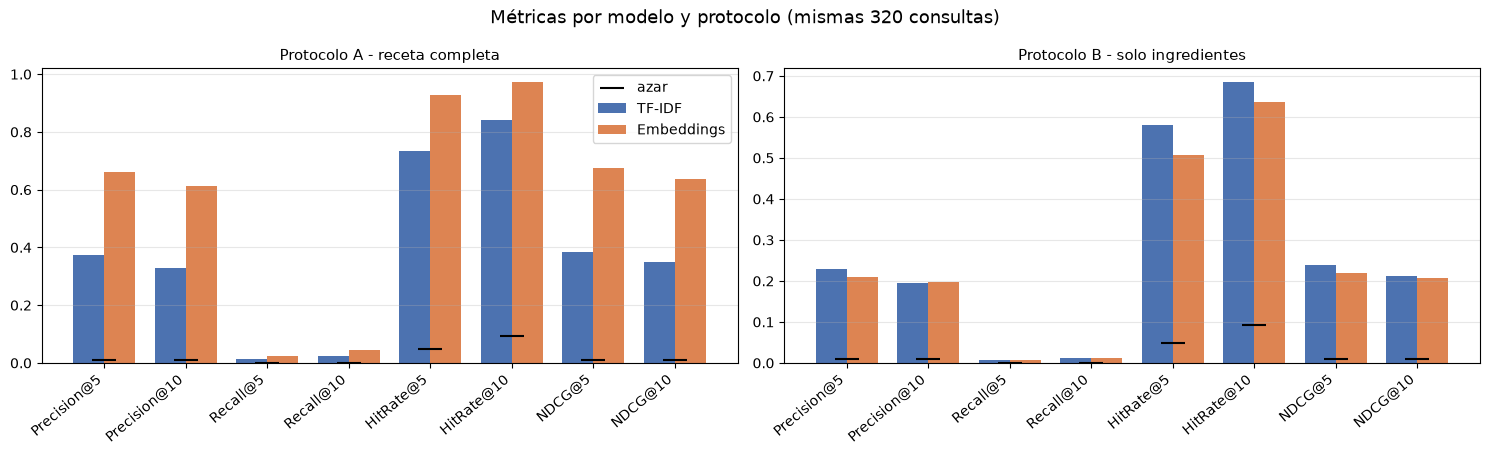

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=False)
width = 0.38
x = np.arange(len(ORDER))
for ax, p in zip(axes, ("A", "B")):
    t = tables[p]
    ax.bar(x - width / 2, t.loc["TF-IDF"], width, label="TF-IDF", color="#4C72B0")
    ax.bar(x + width / 2, t.loc["Embeddings"], width, label="Embeddings", color="#DD8452")
    ax.scatter(x, t.loc["(azar, referencia)"], color="k", marker="_", s=300, label="azar", zorder=3)
    ax.set_xticks(x, ORDER, rotation=40, ha="right")
    ax.set_title(PROTOCOL_NAMES[p].split(":")[0], fontsize=11)
    ax.grid(axis="y", alpha=0.3)
axes[0].legend()
fig.suptitle("Métricas por modelo y protocolo (mismas 320 consultas)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m2_01_metricas_tfidf_vs_embeddings.png", dpi=130)
plt.show()

### 11.2 Desglose por tipo de plato (NDCG@10)
Un promedio global puede esconder que un modelo gana en unos tipos y pierde en otros.

,TF-IDF A,Embeddings A,TF-IDF B,Embeddings B,Δ A (Emb−TF),Δ B (Emb−TF)
group,,,,,,
sandwich,0.326,0.614,0.262,0.061,0.289,-0.201
brochetas,0.274,0.294,0.196,0.035,0.019,-0.160
croquetas,0.534,0.874,0.257,0.124,0.340,-0.133
sopa_caldo,0.488,0.795,0.229,0.101,0.307,-0.128
albondigas,0.428,0.925,0.299,0.174,0.497,-0.125
cupcakes_muffins,0.245,0.837,0.233,0.115,0.592,-0.117
galletas,0.505,0.834,0.315,0.220,0.329,-0.095
coctel_alcohol,0.528,0.716,0.322,0.265,0.188,-0.057
guiso_estofado,0.259,0.523,0.088,0.037,0.264,-0.051


Tipos donde Embeddings supera a TF-IDF en NDCG@10 -> A: 31 de 32 | B: 16 de 32


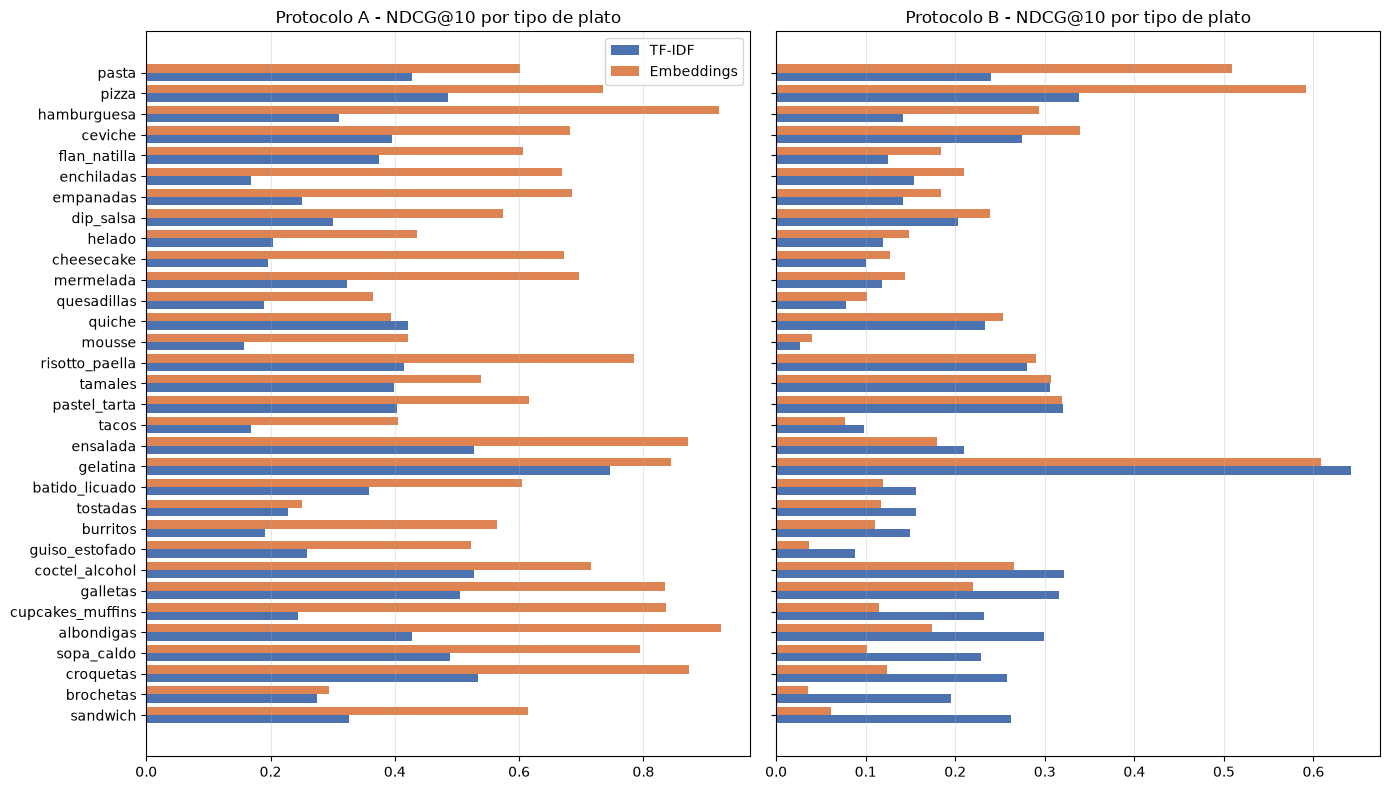

In [19]:
by_group = []
for p in ("A", "B"):
    for model_name in ("TF-IDF", "Embeddings"):
        s = results[(model_name, p)].groupby("group")["NDCG@10"].mean().rename(f"{model_name} {p}")
        by_group.append(s)
by_group = pd.concat(by_group, axis=1)
by_group["Δ A (Emb−TF)"] = by_group["Embeddings A"] - by_group["TF-IDF A"]
by_group["Δ B (Emb−TF)"] = by_group["Embeddings B"] - by_group["TF-IDF B"]
by_group = by_group.sort_values("Δ B (Emb−TF)")
display(by_group.round(3))

print("Tipos donde Embeddings supera a TF-IDF en NDCG@10 -> A:", int((by_group['Δ A (Emb−TF)'] > 0).sum()),
      "de", len(by_group), "| B:", int((by_group['Δ B (Emb−TF)'] > 0).sum()), "de", len(by_group))

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
y = np.arange(len(by_group))
for ax, p in zip(axes, ("A", "B")):
    ax.barh(y - 0.2, by_group[f"TF-IDF {p}"], 0.4, label="TF-IDF", color="#4C72B0")
    ax.barh(y + 0.2, by_group[f"Embeddings {p}"], 0.4, label="Embeddings", color="#DD8452")
    ax.set_title(f"Protocolo {p} - NDCG@10 por tipo de plato")
    ax.grid(axis="x", alpha=0.3)
axes[0].set_yticks(y, by_group.index)
axes[0].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m2_02_ndcg10_por_tipo_de_plato.png", dpi=130)
plt.show()

In [20]:
# Guardar las tablas de resultados (no sobrescribe nada del Modelo 1)
out_dir = ev.EVAL_DIR
for p in ("A", "B"):
    tables[p].round(6).to_csv(out_dir / f"metrics_protocol_{p}.csv")
delta.round(6).to_csv(out_dir / "metrics_delta_bootstrap.csv", index=False)
delta_noleak.round(6).to_csv(out_dir / "metrics_delta_protocol_B_sin_fuga.csv", index=False)
per_query = pd.concat(
    [r.assign(modelo=m, protocolo=p) for (m, p), r in results.items()], ignore_index=True
)
per_query.to_csv(out_dir / "metrics_per_query.csv", index=False)
print("Resultados guardados en", out_dir.relative_to(PROJECT_DIR), "->", sorted(f.name for f in out_dir.iterdir()))

Resultados guardados en data/evaluation -> ['computational_comparison.csv', 'eval_set_v1.json', 'metrics_delta_bootstrap.csv', 'metrics_delta_protocol_B_sin_fuga.csv', 'metrics_per_query.csv', 'metrics_protocol_A.csv', 'metrics_protocol_B.csv']


## 12. Comparación cualitativa

Los casos **no se eligen a mano**: se seleccionan con una regla fija sobre las métricas por consulta, para evitar elegir ejemplos que "se vean bien".

* **Coinciden:** la consulta con mayor solapamiento (Jaccard) entre los Top-10 de ambos modelos.
* **TF-IDF más relevante:** la consulta con mayor `Precision@10(TF-IDF) − Precision@10(Embeddings)` (desempate por NDCG@10).
* **Embeddings más relevante:** la mayor diferencia en sentido contrario.

Marca **✓** = receta del mismo tipo de plato que la consulta según el proxy. **Un "–" no significa necesariamente que la sugerencia sea mala**: p. ej., unas *enchiladas* para unos *tacos* no cuentan como relevantes con este proxy, pero son parecidas. Por eso estas tablas **ilustran** y las **métricas deciden**.

In [21]:
all_groups = ev.assign_groups(df)                                   # tipo de plato de cada receta (o None)
recipe_group = dict(zip(df["recipe_id"], all_groups))
names = dict(zip(df["recipe_id"], df["name"]))


def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)


overlap = {}
for p in ("A", "B"):
    overlap[p] = pd.Series(
        {rid: jaccard(rankings[("TF-IDF", p)][rid], rankings[("Embeddings", p)][rid]) for rid, _ in eval_set.queries}
    )
    print(f"Protocolo {p}: solapamiento medio (Jaccard) entre los Top-10 de TF-IDF y Embeddings = {overlap[p].mean():.3f}"
          f" | consultas con Top-10 idéntico: {(overlap[p] == 1).sum()} | con solapamiento 0: {(overlap[p] == 0).sum()}")


def pick_cases(p):
    t = results[("TF-IDF", p)].set_index("recipe_id")
    e = results[("Embeddings", p)].set_index("recipe_id")
    diff = (e["Precision@10"] - t["Precision@10"]).to_frame("d1").join((e["NDCG@10"] - t["NDCG@10"]).rename("d2"))
    ranked = diff.sort_values(["d1", "d2"])
    return {
        "coinciden": int(overlap[p].sort_values(ascending=False).index[0]),
        "TF-IDF más relevante": int(ranked.index[0]),
        "Embeddings más relevante": int(ranked.index[-1]),
    }


def side_by_side(recipe_id, p, n=10):
    group = dict(eval_set.queries)[recipe_id]
    relevant = eval_set.relevant_for(recipe_id, group)
    cols = {}
    for model_name in ("TF-IDF", "Embeddings"):
        ids_ = rankings[(model_name, p)][recipe_id][:n]
        cols[model_name] = [
            f"{'✓' if rid in relevant else '–'} {names[rid]} [{recipe_group.get(rid) or 'otro'}]" for rid in ids_
        ]
    t = results[("TF-IDF", p)].set_index("recipe_id").loc[recipe_id]
    e = results[("Embeddings", p)].set_index("recipe_id").loc[recipe_id]
    print(f"RECETA DE REFERENCIA: {names[recipe_id]}  (recipe_id={recipe_id}, tipo='{group}', {len(relevant)} relevantes)")
    if p == "B":
        print("   consulta (solo ingredientes):", ingredients_text.iloc[id_to_pos[recipe_id]][:160], "...")
    print(f"   Precision@10: TF-IDF={t['Precision@10']:.1f}  Embeddings={e['Precision@10']:.1f}   |   "
          f"NDCG@10: TF-IDF={t['NDCG@10']:.3f}  Embeddings={e['NDCG@10']:.3f}   |   Jaccard Top-10={overlap[p][recipe_id]:.2f}")
    out = pd.DataFrame(cols, index=range(1, n + 1))
    out.index.name = "rank"
    display(out)

Protocolo A: solapamiento medio (Jaccard) entre los Top-10 de TF-IDF y Embeddings = 0.150 | consultas con Top-10 idéntico: 0 | con solapamiento 0: 41
Protocolo B: solapamiento medio (Jaccard) entre los Top-10 de TF-IDF y Embeddings = 0.078 | consultas con Top-10 idéntico: 0 | con solapamiento 0: 106


In [22]:
cases_A = pick_cases("A")
print("Casos seleccionados (protocolo A):", cases_A, "\n")
for label, rid in cases_A.items():
    print(f"=================  A - {label.upper()}  =================")
    side_by_side(rid, "A")

Casos seleccionados (protocolo A): {'coinciden': 7274, 'TF-IDF más relevante': 19718, 'Embeddings más relevante': 21365} 

=================  A - COINCIDEN  =================
RECETA DE REFERENCIA: Mousse de Lucuma  (recipe_id=7274, tipo='mousse', 164 relevantes)
   Precision@10: TF-IDF=0.1  Embeddings=0.0   |   NDCG@10: TF-IDF=0.064  Embeddings=0.000   |   Jaccard Top-10=0.67


,TF-IDF,Embeddings
rank,,
1,– Torta Tres Leches de Lucuma [otro],– Torta Tres Leches de Lucuma [otro]
2,– Crocante de Lucuma [otro],– QUESO HELADO DE LUCUMA [helado]
3,– Delicia de Lucuma [otro],– Crocante de Lucuma [otro]
4,– QUESO HELADO DE LUCUMA [helado],– Helado de Lucuma [helado]
5,– BAVAROIS DE LUCUMA [otro],– SEMIFREDDO DE LUCUMA [otro]
6,– Helado de Lucuma [helado],– Crema de Lucuma [otro]
7,– CROCANTE DE LUCUMA [otro],– Crema Volteada Peruana [otro]
8,– Crema de Lucuma [otro],– Delicia de Lucuma [otro]
9,– MANJARBLANCO DE LUCUMA [otro],– BAVAROIS DE LUCUMA [otro]


=================  A - TF-IDF MÁS RELEVANTE  =================
RECETA DE REFERENCIA: Brochetas de Langostinos y Pina  (recipe_id=19718, tipo='brochetas', 111 relevantes)
   Precision@10: TF-IDF=0.5  Embeddings=0.1   |   NDCG@10: TF-IDF=0.577  Embeddings=0.110   |   Jaccard Top-10=0.33


,TF-IDF,Embeddings
rank,,
1,✓ Brochetas de Pescado y Langostinos [brochetas],– Ensalada de Langostinos y Fresas [ensalada]
2,– Pastel de Langostinos [otro],– Espinacas con Langostinos [otro]
3,✓ Brochetas de Langostinos [brochetas],✓ Brochetas de Langostinos [brochetas]
4,✓ Brochetas de Pez Espada [brochetas],– Langostinos Fritos [otro]
5,– Pina Rellena de Langostinos [otro],– Pina Rellena de Langostinos [otro]
6,✓ Brochetas de Pollo y Langostinos [brochetas],– Langostinos Cocidos [otro]
7,✓ Brochetas de Pollo con Salsa Yakitori [brochetas],– Deliciosos Pintxos de Esparragos con Langostinos [otro]
8,– Langostinos Cocidos [otro],– Pinchos de Langostinos [otro]
9,– Espinacas con Langostinos [otro],– Ensalada con Pina y Langostinos Deliciosa [ensalada]


=================  A - EMBEDDINGS MÁS RELEVANTE  =================
RECETA DE REFERENCIA: Ensalada de Aguacates y Mejillones  (recipe_id=21365, tipo='ensalada', 1240 relevantes)
   Precision@10: TF-IDF=0.0  Embeddings=1.0   |   NDCG@10: TF-IDF=0.000  Embeddings=1.000   |   Jaccard Top-10=0.00


,TF-IDF,Embeddings
rank,,
1,– Huevos Arzak [otro],✓ Ensalada de Patata y Aguacate [ensalada]
2,– Rabo de Ternera San Fermin [otro],✓ Ensalada de Aguacate y Tomate [ensalada]
3,– Puerros en Vinagreta Cocidos [otro],✓ Ensalada de Aguacate y Mango [ensalada]
4,– Salpicon de Endivias Gallina y Queso [otro],✓ Ensalada de Yuca y Aguacate [ensalada]
5,– Ajos Frescos Habitas y Huevos [otro],✓ Ensalada de Aguacate [ensalada]
6,– Higado de Cordero Salteado [otro],✓ Ensalada de Aguacate y Salmon [ensalada]
7,– Boquerones a la Sidra con Ensalada de Patata [otro],✓ Ensalada de Pasta con Aguacate [ensalada]
8,– Brochetas de Coliflor al Graten [brochetas],✓ Ensalada de Aguacate y Cangrejo [ensalada]
9,– Jarretes de Cordero [otro],✓ Ensalada de Pasta con Salsa de Aguacates [ensalada]


In [23]:
cases_B = pick_cases("B")
print("Casos seleccionados (protocolo B):", cases_B, "\n")
for label, rid in cases_B.items():
    print(f"=================  B - {label.upper()}  =================")
    side_by_side(rid, "B")

Casos seleccionados (protocolo B): {'coinciden': 7274, 'TF-IDF más relevante': 1908, 'Embeddings más relevante': 24790} 

=================  B - COINCIDEN  =================
RECETA DE REFERENCIA: Mousse de Lucuma  (recipe_id=7274, tipo='mousse', 164 relevantes)
   consulta (solo ingredientes): 500 gramos de lúcuma | 347 gramos de queso crema | 250 gramos de leche condensada | 10 gramos de colapez | 10 gramos de agua | 200 gramos de leche evaporada | 1 ...
   Precision@10: TF-IDF=0.0  Embeddings=0.0   |   NDCG@10: TF-IDF=0.000  Embeddings=0.000   |   Jaccard Top-10=0.43


,TF-IDF,Embeddings
rank,,
1,– Torta Tres Leches de Lucuma [otro],– Torta Tres Leches de Lucuma [otro]
2,– Crocante de Lucuma [otro],– Helado de Lucuma [helado]
3,– Delicia de Lucuma [otro],– Crocante de Lucuma [otro]
4,– BAVAROIS DE LUCUMA [otro],– SEMIFREDDO DE LUCUMA [otro]
5,– Fácil Gelatina de Rompope [gelatina],– QUESO HELADO DE LUCUMA [helado]
6,– CROCANTE DE LUCUMA [otro],– Delicia de Lucuma [otro]
7,– Gelatina de Rompope Especial [gelatina],– CROCANTE DE LUCUMA [otro]
8,– Bollos Rellenos de Queso Crema [otro],– Pie de Queso [otro]
9,– QUESO HELADO DE LUCUMA [helado],– Helado de Uchuvas [helado]


=================  B - TF-IDF MÁS RELEVANTE  =================
RECETA DE REFERENCIA: Sandwich de Pavo y Queso  (recipe_id=1908, tipo='sandwich', 242 relevantes)
   consulta (solo ingredientes): 2 rodajas de Pan de molde integral | 3 hojas de Espinaca | 3 rodajas de Cebolla morada | 1 cucharada sopera de Soja germinada | 3 lonchas de Pechuga de pavo ahu ...
   Precision@10: TF-IDF=0.8  Embeddings=0.1   |   NDCG@10: TF-IDF=0.864  Embeddings=0.095   |   Jaccard Top-10=0.00


,TF-IDF,Embeddings
rank,,
1,✓ Club Sandwich Americano [sandwich],– Empanadillas Vegetarianas al Horno [empanadas]
2,✓ Sandwich de Pate [sandwich],– Sopa de Albondigas de Pollo [sopa_caldo]
3,✓ Sandwich de Miga con Zanahoria [sandwich],– Lomo a las Finas Hierbas con Papa [otro]
4,✓ Sandwich Americano con Huevo [sandwich],✓ Sandwich de Tempeh [sandwich]
5,✓ Bocadillos Vegetarianos para Ninos [sandwich],– Lasana de Espinacas [pasta]
6,✓ Sandwich Budapest [sandwich],– Ensalada de Esquites [ensalada]
7,✓ Sandwich de Queso Fundido [sandwich],– Tortitas de Arroz y Espinacas [otro]
8,– Flamenquines de Pan de Molde [otro],– Rollo de Carne Molida [otro]
9,– Budin de Calabaza y Espinaca [otro],– Ensalada con Timbales de Queso [ensalada]


=================  B - EMBEDDINGS MÁS RELEVANTE  =================
RECETA DE REFERENCIA: Pizza de Roquefort  (recipe_id=24790, tipo='pizza', 277 relevantes)
   consulta (solo ingredientes): 1 unid masa para pizza | 4 unids tomates de lata | 1/2 unid cebolla | 1/2 tazas aceite | 250 g queso roquefort | 1 pizca orégano | 1 pizca ají molido ...
   Precision@10: TF-IDF=0.1  Embeddings=1.0   |   NDCG@10: TF-IDF=0.095  Embeddings=1.000   |   Jaccard Top-10=0.05


,TF-IDF,Embeddings
rank,,
1,– Tortilla de Pollo y Papa [otro],✓ Papas Pizza [pizza]
2,– Sopa de Pescado con Name y Ajo [sopa_caldo],✓ Pizza de Cebollas [pizza]
3,– Ensalada de Pollo y Apio [ensalada],✓ Pizza de Mariscos [pizza]
4,✓ Pizza Campesina [pizza],✓ Pizza de Mozzarella al Roquefort [pizza]
5,– Enchiladas Verdes al Horno [enchiladas],✓ Pizza Campesina [pizza]
6,– Tallarines al Pimiento [pasta],✓ Pizza de Atun [pizza]
7,– Risotto Primavera con Apio [risotto_paella],✓ Pizza Arrollada [pizza]
8,– Crema de Apio al Roquefort [otro],✓ Pizza de Pollo Frito [pizza]
9,– Arroz con Puerco y Vegetales [otro],✓ Pizza de Choclos [pizza]


## 13. Rendimiento computacional

Se mide en **procesos nuevos** (un subproceso por modelo) para obtener cifras limpias de carga y memoria. Mismo equipo y mismas 200 consultas (fijadas por semilla) para ambos:

* **Consulta receta→Top-10:** similitud contra las N recetas + ordenamiento.
* **Consulta texto→Top-10:** incluye vectorizar (TF-IDF) o **codificar con el modelo** (embeddings).
* **Memoria:** RSS del proceso (memoria física) antes y después de cargar los artefactos, con las librerías ya importadas; se reporta también el RSS total, que es lo que cuesta realmente servir el modelo.
* Para embeddings se mide en el dispositivo por defecto (aquí, GPU de Apple `mps`) y **también en CPU**, que es lo realista para un servidor sin GPU.

In [24]:
BENCH_SCRIPT = r'''
import json, sys, time
import numpy as np, pandas as pd, psutil

root, kind = sys.argv[1], sys.argv[2]
sys.path.insert(0, root)
proc = psutil.Process()
from src import evaluation as ev

df = pd.read_csv(root + "/data/processed/recetas_unificadas_limpias.csv", usecols=["recipe_id", "ingredients"])
ids = df["recipe_id"].to_numpy()
positions = np.random.default_rng(0).choice(len(df), size=200, replace=False)
text_queries = df["ingredients"].fillna("").iloc[positions[:60]].tolist()

if kind == "tfidf":
    from src.models import load_artifacts
    rss_before = proc.memory_info().rss
    t0 = time.perf_counter(); art = load_artifacts(root + "/models"); load_s = time.perf_counter() - t0
    item = lambda p: (art.matrix @ art.matrix[p].T).toarray().ravel()
    text = art.similarities
else:
    import sentence_transformers, torch
    from src import embeddings as emb
    device = None if kind == "emb" else "cpu"
    rss_before = proc.memory_info().rss
    t0 = time.perf_counter(); art = emb.load_embedding_artifacts(root + "/models", device=device); load_s = time.perf_counter() - t0
    item = art.similarities_to_row
    text = art.similarities
rss_after = proc.memory_info().rss

item(int(positions[0])); text(text_queries[0])          # calentamiento
def timeit(fn, args, excl=None):
    out = []
    for a in args:
        t = time.perf_counter(); s = fn(a); ev.top_k_ids(s, ids, 10, exclude_pos=(a if excl else None)); out.append((time.perf_counter() - t) * 1000)
    return out
it = timeit(item, [int(p) for p in positions], excl=True)
tx = timeit(text, text_queries)
print(json.dumps({
    "load_s": load_s, "rss_before_mb": rss_before / 1e6, "rss_after_mb": rss_after / 1e6,
    "item_median_ms": float(np.median(it)), "item_p95_ms": float(np.percentile(it, 95)),
    "text_median_ms": float(np.median(tx)), "text_p95_ms": float(np.percentile(tx, 95)),
}))
'''


def run_bench(kind):
    proc = subprocess.run(
        [sys.executable, "-c", BENCH_SCRIPT, str(PROJECT_DIR), kind],
        capture_output=True, text=True, check=True,
    )
    return json.loads(proc.stdout.strip().splitlines()[-1])


bench = {k: run_bench(k) for k in ("tfidf", "emb", "emb_cpu")}
display(pd.DataFrame(bench).T.round(2))

,load_s,rss_before_mb,rss_after_mb,item_median_ms,item_p95_ms,text_median_ms,text_p95_ms
tfidf,0.06,256.48,274.02,7.15,10.33,7.31,9.29
emb,1.58,560.50,866.29,2.24,2.43,11.59,16.07
emb_cpu,0.95,560.40,994.77,2.23,2.44,12.64,19.56


In [25]:
# Tiempo de generación de embeddings en CPU: se mide con una muestra y se EXTRAPOLA (estimación, no medición completa)
cpu_model = emb.load_embedding_model(LOCAL_MODEL_DIR if LOCAL_MODEL_DIR.is_dir() else EMBEDDING_MODEL_NAME, device="cpu")
SAMPLE = 512
t0 = time.perf_counter()
emb.encode_texts(cpu_model, texts[:SAMPLE], prefix=PASSAGE_PREFIX)
cpu_sample_s = time.perf_counter() - t0
EMB_BUILD_CPU_ESTIMATE_S = cpu_sample_s / SAMPLE * len(texts)
del cpu_model
print(f"CPU: {SAMPLE} recetas en {cpu_sample_s:.1f} s -> estimación para {len(texts)} recetas: {EMB_BUILD_CPU_ESTIMATE_S / 60:.1f} min (extrapolación lineal)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CPU: 512 recetas en 6.8 s -> estimación para 28853 recetas: 6.3 min (extrapolación lineal)


In [26]:
def sparse_bytes(m):
    return m.data.nbytes + m.indices.nbytes + m.indptr.nbytes


def mb(x):
    return f"{x / 1e6:,.1f} MB"


def disk(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file())


tf_files = disk(MODELS_DIR / "recipe_tfidf_matrix.joblib")
tf_vec = disk(MODELS_DIR / "tfidf_vectorizer.joblib")
em_matrix_file = disk(MODELS_DIR / emb.EMBEDDINGS_FILENAME)
em_model_dir = disk(LOCAL_MODEL_DIR) if LOCAL_MODEL_DIR.is_dir() else float("nan")
nnz = tfidf_matrix.nnz
b_t, b_e, b_c = bench["tfidf"], bench["emb"], bench["emb_cpu"]

comparison = pd.DataFrame(
    {
        "TF-IDF": [
            "sparse (CSR, float64)", f"{tfidf_matrix.shape[1]:,} términos",
            f"{nnz:,} ({nnz / len(df):.0f} por receta; {nnz / np.prod(tfidf_matrix.shape):.3%} de la matriz)",
            f"{TFIDF_BUILD_SECONDS:.1f} s (CPU, un hilo)", mb(sparse_bytes(tfidf_matrix)),
            f"matriz {mb(tf_files)} + vectorizador {mb(tf_vec)}", "no (solo el vectorizador de 1.6 MB)",
            f"{b_t['load_s']:.2f} s", f"{b_t['rss_after_mb']:.0f} MB (+{b_t['rss_after_mb'] - b_t['rss_before_mb']:.0f} MB por cargar)",
            f"{b_t['item_median_ms']:.1f} ms (p95 {b_t['item_p95_ms']:.1f})", f"{b_t['text_median_ms']:.1f} ms (p95 {b_t['text_p95_ms']:.1f})",
        ],
        "Embeddings": [
            "dense (float32)", f"{E.shape[1]} dimensiones", f"{E.size:,} (100 %)",
            f"{meta['build_seconds']:.0f} s en '{meta['device']}'  |  ~{EMB_BUILD_CPU_ESTIMATE_S:.0f} s estimados en CPU",
            mb(E.nbytes), f"matriz {mb(em_matrix_file)}", f"sí: modelo de {mb(em_model_dir)} en models/embedding_model/",
            f"{b_e['load_s']:.2f} s ('{meta['device']}') | {b_c['load_s']:.2f} s (CPU)",
            f"{b_e['rss_after_mb']:.0f} MB (+{b_e['rss_after_mb'] - b_e['rss_before_mb']:.0f} MB) ('{meta['device']}') | {b_c['rss_after_mb']:.0f} MB (+{b_c['rss_after_mb'] - b_c['rss_before_mb']:.0f} MB) (CPU)",
            f"{b_e['item_median_ms']:.1f} ms (p95 {b_e['item_p95_ms']:.1f})",
            f"{b_e['text_median_ms']:.1f} ms (p95 {b_e['text_p95_ms']:.1f}) en '{meta['device']}' | {b_c['text_median_ms']:.1f} ms (p95 {b_c['text_p95_ms']:.1f}) en CPU",
        ],
    },
    index=[
        "Representación", "Dimensión", "Valores almacenados", "Tiempo de construcción", "Tamaño en memoria (matriz)",
        "Tamaño en disco", "Modelo externo requerido", "Tiempo de carga (arranque)", "Memoria del proceso (RSS)",
        "Consulta receta→Top-10 (mediana)", "Consulta texto→Top-10 (mediana)",
    ],
)
comparison.index.name = "Característica"
with pd.option_context("display.max_colwidth", None):
    display(comparison)
comparison.to_csv(ev.EVAL_DIR / "computational_comparison.csv")

,TF-IDF,Embeddings
Característica,,
Representación,"sparse (CSR, float64)",dense (float32)
Dimensión,"63,143 términos",384 dimensiones
Valores almacenados,"2,080,222 (72 por receta; 0.114% de la matriz)","11,079,552 (100 %)"
Tiempo de construcción,"1.2 s (CPU, un hilo)",82 s en 'mps:0' | ~381 s estimados en CPU
Tamaño en memoria (matriz),25.1 MB,44.3 MB
Tamaño en disco,matriz 25.1 MB + vectorizador 1.6 MB,matriz 44.3 MB
Modelo externo requerido,no (solo el vectorizador de 1.6 MB),sí: modelo de 488.2 MB en models/embedding_model/
Tiempo de carga (arranque),0.06 s,1.58 s ('mps:0') | 0.95 s (CPU)
Memoria del proceso (RSS),274 MB (+18 MB por cargar),866 MB (+306 MB) ('mps:0') | 995 MB (+434 MB) (CPU)


## 14. Resumen automático de resultados

Esta celda **no contiene números escritos a mano**: lee las tablas calculadas arriba y enuncia qué métricas mejoraron, cuáles empeoraron y cuáles no cambiaron de forma distinguible (IC95 % del bootstrap incluye 0).

In [27]:
for p in ("A", "B"):
    d = delta[delta["Protocolo"] == p]
    print(f"===== {PROTOCOL_NAMES[p]}")
    for verdict in ("Embeddings mejor", "TF-IDF mejor", "sin diferencia clara"):
        sub = d[d["Veredicto"] == verdict]
        txt = ", ".join(f"{r['Métrica']} ({r['Δ abs (Emb − TF-IDF)']:+.4f}, {r['Δ relativa']:+.1%})" for _, r in sub.iterrows()) or "-"
        print(f"  {verdict:<22}: {txt}")
    best = "Embeddings" if tables[p].loc["Embeddings", "NDCG@10"] > tables[p].loc["TF-IDF", "NDCG@10"] else "TF-IDF"
    print(f"  Mayor NDCG@10 en este protocolo: {best}\n")

print("Costo: construcción  TF-IDF %.1f s vs embeddings %.0f s (%s) -> %.0fx" % (
    TFIDF_BUILD_SECONDS, meta["build_seconds"], meta["device"], meta["build_seconds"] / TFIDF_BUILD_SECONDS))
print("       RSS tras cargar (CPU)  TF-IDF %.0f MB vs embeddings %.0f MB" % (b_t["rss_after_mb"], b_c["rss_after_mb"]))
print("       consulta de texto (CPU) TF-IDF %.1f ms vs embeddings %.1f ms" % (b_t["text_median_ms"], b_c["text_median_ms"]))

===== Protocolo A - receta completa: recomendar_similares(recipe_id)
  Embeddings mejor      : Precision@5 (+0.2875, +76.8%), Precision@10 (+0.2816, +85.2%), Recall@5 (+0.0104, +77.1%), Recall@10 (+0.0203, +86.3%), HitRate@5 (+0.1938, +26.4%), HitRate@10 (+0.1313, +15.6%), NDCG@5 (+0.2902, +75.3%), NDCG@10 (+0.2850, +81.2%)
  TF-IDF mejor          : -
  sin diferencia clara  : -
  Mayor NDCG@10 en este protocolo: Embeddings

===== Protocolo B - solo ingredientes: recomendar_por_texto(ingredientes)
  Embeddings mejor      : -
  TF-IDF mejor          : HitRate@5 (-0.0750, -12.9%)
  sin diferencia clara  : Precision@5 (-0.0194, -8.5%), Precision@10 (+0.0016, +0.8%), Recall@5 (-0.0007, -8.8%), Recall@10 (+0.0000, +0.2%), HitRate@10 (-0.0469, -6.8%), NDCG@5 (-0.0206, -8.6%), NDCG@10 (-0.0057, -2.7%)
  Mayor NDCG@10 en este protocolo: TF-IDF

Costo: construcción  TF-IDF 1.2 s vs embeddings 82 s (mps:0) -> 67x
       RSS tras cargar (CPU)  TF-IDF 274 MB vs embeddings 995 MB
       consulta de

## 15. Conclusiones

> Todas las cifras de esta sección provienen de la ejecución registrada arriba (320 consultas, K = 5 y 10, mismo conjunto de evaluación para ambos modelos). Los tiempos son de **un** equipo (Apple Silicon, GPU `mps`) y varían de una ejecución a otra; las diferencias de calidad no.

### 1. ¿Qué modelo obtuvo mejores métricas?
**Depende del protocolo, y los dos son importantes:**

* **Protocolo A (receta → recetas parecidas, `recomendar_similares`): Embeddings, claramente.** Mejoró las 8 métricas y en todas el IC95 % del bootstrap excluye 0.
* **Protocolo B (solo ingredientes → recetas, `recomendar_por_texto`): no hay mejora de Embeddings.** TF-IDF es igual o ligeramente mejor.

### 2. ¿En qué métricas mejoró? (Embeddings − TF-IDF, protocolo A)
| Métrica | TF-IDF | Embeddings | Δ abs | Δ relativa | IC95 % de Δ |
|---|---|---|---|---|---|
| Precision@5 | 0.374 | 0.662 | +0.288 | +76.8 % | [+0.254, +0.323] |
| Precision@10 | 0.330 | 0.612 | +0.282 | +85.2 % | [+0.251, +0.313] |
| Recall@5 | 0.0135 | 0.0239 | +0.0104 | +77.1 % | [+0.0086, +0.0123] |
| Recall@10 | 0.0235 | 0.0437 | +0.0203 | +86.3 % | [+0.0169, +0.0238] |
| HitRate@5 | 0.734 | 0.928 | +0.194 | +26.4 % | [+0.147, +0.244] |
| HitRate@10 | 0.841 | 0.972 | +0.131 | +15.6 % | [+0.094, +0.172] |
| NDCG@5 | 0.386 | 0.676 | +0.290 | +75.3 % | [+0.256, +0.325] |
| NDCG@10 | 0.351 | 0.636 | +0.285 | +81.2 % | [+0.254, +0.317] |

La mejora es amplia: Embeddings supera a TF-IDF en NDCG@10 en **31 de los 32 tipos de plato** (la excepción es `quiche`, −0.026). Referencia de ranking al azar: Precision@10 = 0.010 y HitRate@10 = 0.093, así que ambos modelos están muy por encima del azar. *(Recall es pequeño en términos absolutos porque cada consulta tiene decenas o cientos de relevantes; sirve para comparar, no como valor absoluto.)*

### 3. ¿En cuáles empeoró?
En el protocolo A, en ninguna. En el protocolo B ninguna métrica mejora de forma distinguible del ruido (Precision@10 y Recall@10 son prácticamente iguales) y **HitRate@5 empeora** (0.581 → 0.506; Δ = −0.075, IC95 % [−0.134, −0.016]); las demás diferencias de B tienen un intervalo que incluye 0 (p. ej. NDCG@10: 0.213 → 0.207, Δ = −0.006, IC95 % [−0.031, +0.020]). Al quitar las 56 consultas con fuga léxica (264 restantes), TF-IDF resulta además mejor en Precision@5 (−0.036), HitRate@5 (−0.076) y NDCG@5 (−0.038), con IC95 % que excluyen 0; el resto sigue sin diferencia clara. Por tipo de plato, en B Embeddings gana en 16 de 32 y pierde en los otros 16: mejora con `pasta` (+0.269), `pizza` (+0.254) y `hamburguesa` (+0.153), y empeora con `sandwich` (−0.201), `brochetas` (−0.160), `croquetas` (−0.133) y `sopa_caldo` (−0.128).

### 4. ¿Cuánto cambió?
En A, el NDCG@10 casi se duplica (0.351 → 0.636, +81 %) y la proporción de consultas con al menos un acierto en el Top-5 sube de 73 % a 93 %. En B el cambio es de −3 % en NDCG@10 (dentro del ruido estadístico) y −13 % en HitRate@5 (diferencia distinguible del azar).

### 5. ¿Los embeddings producen recomendaciones cualitativamente diferentes?
Sí, y mucho. El solapamiento medio (Jaccard) entre los Top-10 de ambos modelos es **0.15 en A** y **0.08 en B**; ninguna consulta tiene Top-10 idéntico, y 41 consultas en A (106 en B) no comparten ninguna receta. Lo observado en los ejemplos (sección 12) y en la demostración de la sección 8.3: TF-IDF no relaciona palabras distintas (`jitomate`/`tomate` = 0.000) y sus vecinos dependen de coincidencias de ingredientes (para *Tacos de Cerdo con Salsa Roja* sugiere sobre todo platos con cerdo y salsa); los embeddings agrupan por tipo de plato (devuelve tacos, tostadas y carnitas). **Hipótesis (no comprobada en este notebook):** en el protocolo A, `recipe_text` tiene ~70 palabras en total (mediana ≈ 66) y el nombre son solo 3-5 de ellas, lo que diluye el nombre en el vector TF-IDF y no tanto en el embedding. Los ejemplos también muestran la cara opuesta: cuando la consulta tiene un ingrediente raro y dominante (*Mousse de Lucuma*), ambos modelos devuelven postres de lúcuma, que el proxy cuenta como no relevantes aunque a una persona probablemente le parezcan razonables.

### 6. ¿Cuál tiene mayor costo computacional?
**Embeddings**, en casi todo, pero con matices:

| | TF-IDF | Embeddings |
|---|---|---|
| Construcción | 1.2 s | 82 s en GPU `mps` (≈ 381 s estimados en CPU a partir de 512 recetas) |
| Matriz en memoria | 25.1 MB | 44.3 MB |
| Modelo externo | no (1.6 MB de vectorizador) | sí, 488 MB en disco + `torch` |
| Memoria del proceso tras cargar | 274 MB | 709-866 MB (GPU, variable) / 995 MB (CPU) |
| Arranque | 0.06 s | 1.0-1.6 s |
| Consulta receta → Top-10 | 7.2 ms | **2.2 ms** |
| Consulta texto → Top-10 | 7.3 ms | 11.6-12.6 ms |

Matiz importante: para el caso receta → recetas parecidas, el servidor **no necesita cargar el modelo ni `torch`**, solo la matriz de 44 MB (el producto punto sale más rápido que el TF-IDF disperso). El costo fuerte aparece cuando hay que codificar **texto libre en tiempo real**. Todas las latencias medidas son muy bajas para este tamaño de catálogo.

### 7. ¿Cuál parece más adecuado como siguiente baseline del proyecto?
Según estos resultados, **no hay un único ganador; depende del flujo**:

* **Recetas parecidas a una receta dada** (aún no existe en el backend): **Embeddings** es el mejor candidato. La mejora es grande, consistente (31/32 tipos) y se obtuvo pese a que la relevancia se define desde el nombre, lo cual en principio *favorece* a los métodos léxicos; además no exige torch en producción.
* **Búsquedas por texto / ingredientes** (los flujos actuales de "Con lo que tengo" y "Sorpréndeme" usan TF-IDF sobre texto): **no hay evidencia de que Embeddings mejore**; con estas consultas, TF-IDF iguala o supera en el Top-5 y es mucho más barato. **Conviene conservar TF-IDF como baseline** en ese flujo.

Esta es una lectura de las métricas, no una decisión: antes de integrar nada convendría validar con consultas escritas como las escribiría una persona (cortas, sin cantidades), que este experimento no cubre.

### 8. ¿Qué limitaciones siguen existiendo?
1. **La relevancia es un proxy** (mismo tipo de plato según una taxonomía nuestra, derivada del nombre), no juicios humanos ni interacciones de usuarios. Mide "tipo de plato", no gusto, y subestima ambos modelos cuando recomiendan platos razonables de otro tipo (*lúcuma*, *enchiladas* para *tacos*). Otra definición de relevancia podría cambiar las diferencias.
2. **El protocolo A está parcialmente circular** (el nombre está en la consulta y define la etiqueta). El bootstrap cuantifica la incertidumbre por muestreo de consultas, **no** por la elección de la taxonomía.
3. **El protocolo B usa listas de ingredientes con cantidades** copiadas del CSV, distintas de lo que escribiría un usuario; las consultas de "antojos" de Sorpréndeme (`rápido`, `dulce`...) no se evaluaron; 17.5 % de las consultas B conserva fuga léxica (se hizo la sensibilidad sin ellas).
4. **Un solo modelo de embeddings**, elegido a priori y sin ajuste: no se probó `multilingual-e5-base`, `bge-m3` ni otras configuraciones de prefijos. No se probó un modelo híbrido (TF-IDF + embeddings) ni *fine-tuning* con recetas.
5. **Etiquetas incompletas:** recetas de un mismo tipo con otro nombre o sin `app_category` cuentan como no relevantes para ambos modelos. Hay ruido en `app_category` de origen (p. ej. pasteles salados en postres).
6. **Solo K = 5 y 10**, 320 consultas (10 por tipo), un solo equipo para los tiempos; la estimación de tiempo en CPU es una extrapolación lineal de 512 recetas.
7. **Ninguno de los dos modelos incorpora tiempo, dificultad, rating ni preferencias del usuario**, que el backend sí aplica como filtros y reordenamiento.

**Siguientes pasos razonables:** (a) definir relevancia con una fuente independiente del nombre (p. ej., juicios manuales sobre una muestra pequeña) para confirmar el resultado de A; (b) evaluar consultas cortas tipo usuario; (c) probar un híbrido TF-IDF + embeddings; (d) solo entonces decidir qué integrar al backend.

## 16. Cómo reproducir todo desde cero

```bash
cd chefWise
source .venv/bin/activate
pip install -r requirements.txt                 # incluye sentence-transformers

# (opcional) forzar regeneración de lo calculado por este notebook:
rm -f models/recipe_embeddings.npy models/embedding_metadata.json   # se regeneran (~3 min en Apple GPU)
rm -f data/evaluation/eval_set_v1.json                              # se recrea con la misma semilla (idéntico)

jupyter nbconvert --to notebook --execute --inplace notebooks/04_recomendador_embeddings.ipynb
python -m pytest -q                              # incluye las pruebas de las métricas
```

| Qué | Dónde |
|---|---|
| Modelo de embeddings (una sola constante) | `src/embeddings.py` → `EMBEDDING_MODEL_NAME` (o `CHEFWISE_EMBEDDING_MODEL`) |
| Embeddings guardados | `models/recipe_embeddings.npy` + `models/embedding_metadata.json` |
| Copia local del modelo (sin red) | `models/embedding_model/` (en `.gitignore`: se vuelve a descargar de Hugging Face) |
| Conjunto de evaluación congelado | `data/evaluation/eval_set_v1.json` |
| Resultados exportados | `data/evaluation/metrics_*.csv`, `computational_comparison.csv` |
| Código reutilizable | `src/evaluation.py` (métricas y conjunto), `src/embeddings.py` (Modelo 2) |
| Modelo 1 (intacto) | `models/tfidf_vectorizer.joblib`, `models/recipe_tfidf_matrix.joblib` |